# Phase 3: Classification — FD003

## Step 0: Setup — Config, Folders, and Random Seed
Set up the environment, define directories, and ensure reproducibility with a random seed.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Manual config — since we're inside notebooks/phase3, go two levels up
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
REPORT_DIR = os.path.join(BASE_DIR, 'report')
CLASSIF_REPORT_DIR = os.path.join(REPORT_DIR, 'classification', 'FD003')  # Adjusted for FD003

RANDOM_STATE = 42  # Global seed

# Set consistent plotting aesthetics
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Set reproducibility
np.random.seed(RANDOM_STATE)

# Create required folders
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(CLASSIF_REPORT_DIR, exist_ok=True)

# Confirm setup
print(f" Figures directory ready: {FIGURES_DIR}")
print(f" Models directory ready: {MODELS_DIR}")
print(f" Classification report directory ready: {CLASSIF_REPORT_DIR}")
print(f" Random seed set: {RANDOM_STATE}")
print("✅ Step 0 complete — Phase 3 (FD003) setup initialized.\n")

 Figures directory ready: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3
 Models directory ready: c:\Users\pandr\hybrid-predictive-maintenance\models
 Classification report directory ready: c:\Users\pandr\hybrid-predictive-maintenance\report\classification\FD003
 Random seed set: 42
✅ Step 0 complete — Phase 3 (FD003) setup initialized.



## Step 1: Load Cleaned + Final Cluster-Labeled FD003 Dataset
Load the FD003 training dataset and perform basic validation and exploration.

In [2]:
import pandas as pd
import os

# Define BASE_DIR relative to this notebook location
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))

# File path to labeled FD003 dataset
DATA_FILE_FD003 = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD003.csv')

# Load the dataset
df_fd003 = pd.read_csv(DATA_FILE_FD003)
print(f" FD003 dataset loaded from: {DATA_FILE_FD003}")

# --- Validate structure ---
assert 'final_stage' in df_fd003.columns, "'final_stage' column missing in dataset."

# Show head of the dataset
print("\n Preview — First 5 rows:")
print(df_fd003.head())

# Dataset information
print("\nℹ Dataset Info:")
print(df_fd003.info())

# Check for missing values
nulls = df_fd003.isnull().sum()
if nulls.any():
    print("\n Missing values found:")
    print(nulls[nulls > 0])
else:
    print("\n No missing values.")

# Class distribution (0–4 stages)
print("\n Final Stage Distribution (Count per Class):")
print(df_fd003['final_stage'].value_counts().sort_index())

 FD003 dataset loaded from: c:\Users\pandr\hybrid-predictive-maintenance\data\corrected_clustered_train_FD003.csv

 Preview — First 5 rows:
   unit  time  op_setting_1  op_setting_2  op_setting_3  sensor_2  sensor_3  \
0     1     1       -0.0005        0.0004         100.0  0.355972  0.370523   
1     1     2        0.0008       -0.0003         100.0  0.388759  0.399100   
2     1     3       -0.0014       -0.0002         100.0  0.313817  0.353298   
3     1     4       -0.0020        0.0001         100.0  0.487119  0.417107   
4     1     5        0.0016        0.0000         100.0  0.196721  0.476218   

   sensor_4  sensor_6  sensor_7  ...  sensor_17  sensor_20  sensor_21  \
0  0.308580       1.0  0.208812  ...   0.272727   0.559524   0.446331   
1  0.309360       1.0  0.236590  ...   0.363636   0.488095   0.534836   
2  0.445398       1.0  0.230843  ...   0.272727   0.404762   0.458577   
3  0.237285       1.0  0.268199  ...   0.363636   0.470238   0.391966   
4  0.321217       1.

## Step 2: Feature and Target Setup
Define features (sensor columns) and target (final_stage) for classification.

In [3]:
# Feature and target setup
df = df_fd003.copy()

# Dynamically select all usable sensor columns
selected_features = [col for col in df.columns if col.startswith("sensor_")]

# Extract features and target
X_fd003 = df[selected_features]
y_fd003 = df['final_stage']

# Display shapes and stats
print(f"✅ Selected features: {len(selected_features)} sensors → {selected_features}")
print("🔹 Input Features (X) shape:", X_fd003.shape)
print("🔹 Target (y) shape:", y_fd003.shape)

# Basic stats
print("\n📊 Feature Stats Summary:")
print(X_fd003.describe())

# Target class distribution
print("\n📊 Class Distribution in y:")
print(y_fd003.value_counts())

✅ Selected features: 16 sensors → ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
🔹 Input Features (X) shape: (24720, 16)
🔹 Target (y) shape: (24720,)

📊 Feature Stats Summary:
           sensor_2      sensor_3      sensor_4      sensor_6      sensor_7  \
count  24720.000000  24720.000000  24720.000000  24720.000000  24720.000000   
mean       0.378889      0.465437      0.427632      0.911506      0.265029   
std        0.122490      0.133302      0.152468      0.113225      0.164624   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.290398      0.371501      0.314002      0.812500      0.167625   
50%        0.365340      0.454492      0.403276      0.937500      0.212644   
75%        0.456674      0.550254      0.523245      1.000000      0.307950   
max        1.000000      1.000000    

## Step 3: Engine-Wise Stratified Train-Test Split
Perform an engine-wise stratified split to create training and validation sets.

In [4]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Map each engine ID to its first degradation stage
engine_stage_map = df_fd003.groupby('unit')['final_stage'].first()

# Unique engines and corresponding first-stage labels
unique_units = engine_stage_map.index
first_stage_labels = engine_stage_map.values

# Stratified train-test engine split (80/20)
train_units, val_units = train_test_split(
    unique_units,
    test_size=0.2,
    stratify=first_stage_labels,  # ensures class balance across engines
    random_state=RANDOM_STATE
)

# Filter full-cycle data for each engine set
train_df = df_fd003[df_fd003['unit'].isin(train_units)].reset_index(drop=True)
val_df = df_fd003[df_fd003['unit'].isin(val_units)].reset_index(drop=True)

# Extract input features and class labels
X_train_fd003 = train_df[selected_features]
y_train_fd003 = train_df['final_stage']
X_val_fd003 = val_df[selected_features]
y_val_fd003 = val_df['final_stage']

# Summary
print(" Train Set Shape:", X_train_fd003.shape, f"→ Unique Units: {train_df['unit'].nunique()}")
print(" Validation Set Shape:", X_val_fd003.shape, f"→ Unique Units: {val_df['unit'].nunique()}")

print("\n Train Final Stage Distribution:")
print(y_train_fd003.value_counts(normalize=True).sort_index().apply(lambda x: f"{x:.2%}"))

print("\n Validation Final Stage Distribution:")
print(y_val_fd003.value_counts(normalize=True).sort_index().apply(lambda x: f"{x:.2%}"))

 Train Set Shape: (19845, 16) → Unique Units: 80
 Validation Set Shape: (4875, 16) → Unique Units: 20

 Train Final Stage Distribution:
final_stage
0     4.71%
1     6.98%
2    18.04%
3    28.31%
4    41.96%
Name: proportion, dtype: object

 Validation Final Stage Distribution:
final_stage
0     5.27%
1     7.30%
2    20.31%
3    29.39%
4    37.72%
Name: proportion, dtype: object


## Step 4: Train & Evaluate Random Forest Classifier
Train a Random Forest classifier, evaluate it with cross-validation, and log results.

RF 5-Fold CV F1 Scores: [0.95888018 0.96292408 0.96072077 0.95987527 0.95969982]
RF Mean F1 Score: 0.9604

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       257
           1       0.97      0.96      0.97       356
           2       0.93      0.96      0.94       990
           3       0.97      0.99      0.98      1433
           4       0.97      0.94      0.96      1839

    accuracy                           0.96      4875
   macro avg       0.96      0.96      0.96      4875
weighted avg       0.96      0.96      0.96      4875

Stage 3 F1 Score: 0.9813
Stage 4 F1 Score: 0.9564


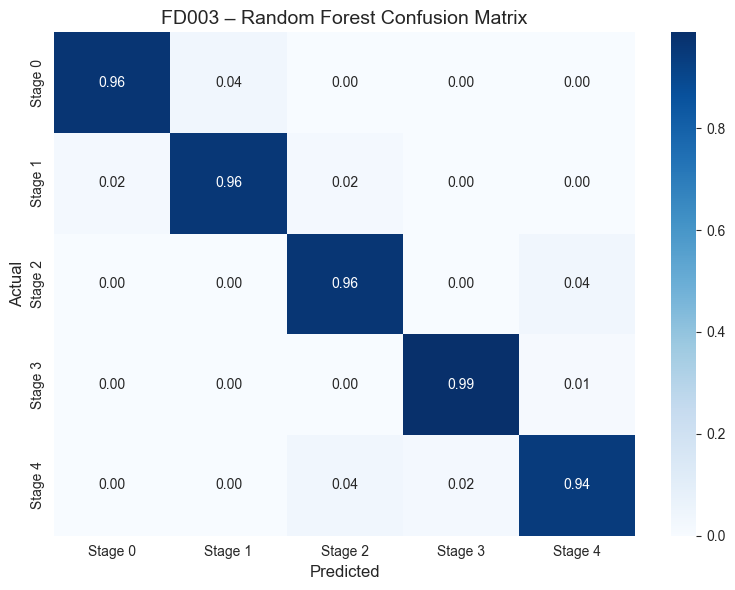

Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\rf_classifier_fd003.pkl
Confusion matrix saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd003_confusion_matrix.png
Prediction log saved: c:\Users\pandr\hybrid-predictive-maintenance\report\classification\FD003\predictions_fd003_rf.csv
Misclassified samples saved: c:\Users\pandr\hybrid-predictive-maintenance\report\classification\FD003\misclassified_fd003_rf.csv


In [5]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

# --- Random Forest Model ---
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

# --- Cross-Validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf, X_train_fd003, y_train_fd003, cv=cv, scoring='f1_weighted')
print("RF 5-Fold CV F1 Scores:", cv_scores)
print("RF Mean F1 Score: {:.4f}".format(cv_scores.mean()))

# --- Train + Predict ---
rf.fit(X_train_fd003, y_train_fd003)
y_pred = rf.predict(X_val_fd003)
proba = rf.predict_proba(X_val_fd003)
stage4_idx = list(rf.classes_).index(4)
prob_stage4 = proba[:, stage4_idx]
confidence = proba.max(axis=1)

# --- Evaluation ---
print("\nClassification Report:")
print(classification_report(y_val_fd003, y_pred))
report = classification_report(y_val_fd003, y_pred, output_dict=True)
print(f"Stage 3 F1 Score: {report['3']['f1-score']:.4f}")
print(f"Stage 4 F1 Score: {report['4']['f1-score']:.4f}")

# --- Confusion Matrix ---
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(y_val_fd003, y_pred, labels=labels, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=[f"Stage {i}" for i in labels],
            yticklabels=[f"Stage {i}" for i in labels])
plt.title("FD003 – Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

# --- Save Outputs ---
model_path = os.path.join(MODELS_DIR, 'rf_classifier_fd003.pkl')
conf_matrix_path = os.path.join(FIGURES_DIR, 'rf_fd003_confusion_matrix.png')
joblib.dump(rf, model_path)
plt.savefig(conf_matrix_path)
plt.show()
plt.close()
print(f"Model saved to: {model_path}")
print(f"Confusion matrix saved to: {conf_matrix_path}")

# --- Save Logs ---
val_df = val_df.reset_index(drop=True)
val_df['y_true'] = y_val_fd003.values
val_df['y_pred'] = y_pred
val_df['prob_stage4'] = prob_stage4
val_df['confidence'] = confidence
pred_log = os.path.join(CLASSIF_REPORT_DIR, 'predictions_fd003_rf.csv')
misclassified_log = os.path.join(CLASSIF_REPORT_DIR, 'misclassified_fd003_rf.csv')
val_df.to_csv(pred_log, index=False)
val_df[val_df['y_true'] != val_df['y_pred']].to_csv(misclassified_log, index=False)
print(f"Prediction log saved: {pred_log}")
print(f"Misclassified samples saved: {misclassified_log}")

## Step 5: SVM Classifier + Cross-Validation + Evaluation
Train an SVM classifier, evaluate it, and save the results.

SVM 5-Fold CV Weighted F1 Scores: [0.98160258 0.98387764 0.98014071 0.98061808 0.98061224]
SVM Mean F1 Score: 0.9814

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       257
           1       0.99      0.98      0.99       356
           2       0.96      1.00      0.98       990
           3       0.99      1.00      0.99      1433
           4       1.00      0.97      0.98      1839

    accuracy                           0.99      4875
   macro avg       0.99      0.99      0.99      4875
weighted avg       0.99      0.99      0.99      4875

Stage 3 F1 Score: 0.9941
Stage 4 F1 Score: 0.9848


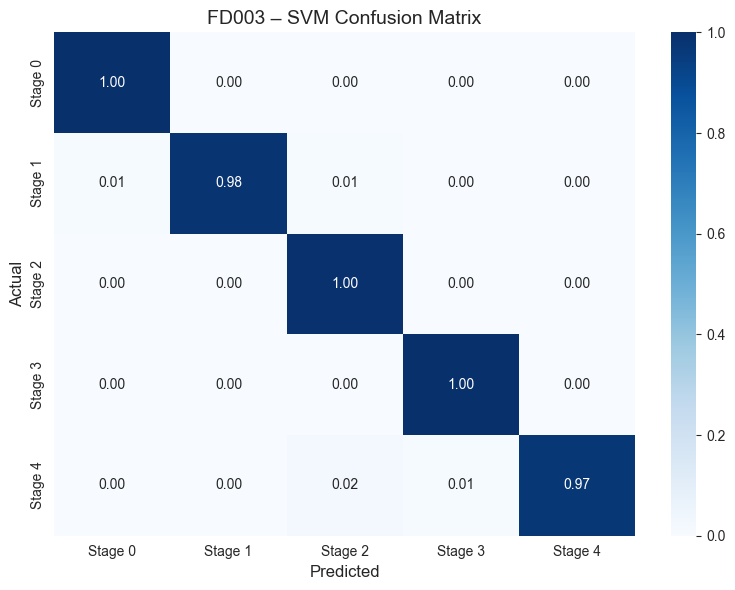

✅ All outputs saved for SVM Classifier (FD003).


In [6]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

# --- Model ---
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced',
              probability=True, random_state=RANDOM_STATE)

# --- CV ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(svm_clf, X_train_fd003, y_train_fd003, cv=cv, scoring='f1_weighted')
print("SVM 5-Fold CV Weighted F1 Scores:", scores)
print("SVM Mean F1 Score: {:.4f}".format(scores.mean()))

# --- Train ---
svm_clf.fit(X_train_fd003, y_train_fd003)

# --- Predict ---
y_pred = svm_clf.predict(X_val_fd003)
proba = svm_clf.predict_proba(X_val_fd003)
stage4_idx = list(svm_clf.classes_).index(4)
prob_stage4 = proba[:, stage4_idx]
confidence = proba.max(axis=1)

# --- Evaluation ---
print("\nClassification Report:")
print(classification_report(y_val_fd003, y_pred))
report = classification_report(y_val_fd003, y_pred, output_dict=True)
print(f"Stage 3 F1 Score: {report['3']['f1-score']:.4f}")
print(f"Stage 4 F1 Score: {report['4']['f1-score']:.4f}")

# --- Confusion Matrix ---
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(y_val_fd003, y_pred, labels=labels, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f"Stage {l}" for l in labels],
            yticklabels=[f"Stage {l}" for l in labels])
plt.title("FD003 – SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

# --- Save ---
joblib.dump(svm_clf, os.path.join(MODELS_DIR, 'svm_classifier_fd003.pkl'))
plt.savefig(os.path.join(FIGURES_DIR, 'svm_fd003_confusion_matrix.png'))
plt.show()
plt.close()

val_df = val_df.reset_index(drop=True)
val_df['y_true'] = y_val_fd003.values
val_df['y_pred'] = y_pred
val_df['prob_Stage4'] = prob_stage4
val_df['confidence'] = confidence
val_df.to_csv(os.path.join(CLASSIF_REPORT_DIR, 'predictions_fd003_svm.csv'), index=False)
val_df[val_df['y_true'] != val_df['y_pred']].to_csv(os.path.join(CLASSIF_REPORT_DIR, 'misclassified_fd003_svm.csv'), index=False)
print("✅ All outputs saved for SVM Classifier (FD003).")

## Step 6: Logistic Regression Classifier
Train a Logistic Regression classifier and evaluate its performance.

LR 5-Fold CV F1 Scores: [0.97203057 0.976564   0.97254914 0.97459022 0.97228618]
LR Mean F1 Score: 0.9736

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       257
           1       0.99      0.96      0.98       356
           2       0.95      0.99      0.97       990
           3       0.97      1.00      0.99      1433
           4       1.00      0.96      0.98      1839

    accuracy                           0.98      4875
   macro avg       0.98      0.98      0.98      4875
weighted avg       0.98      0.98      0.98      4875

Stage 3 F1 Score: 0.9862
Stage 4 F1 Score: 0.9775


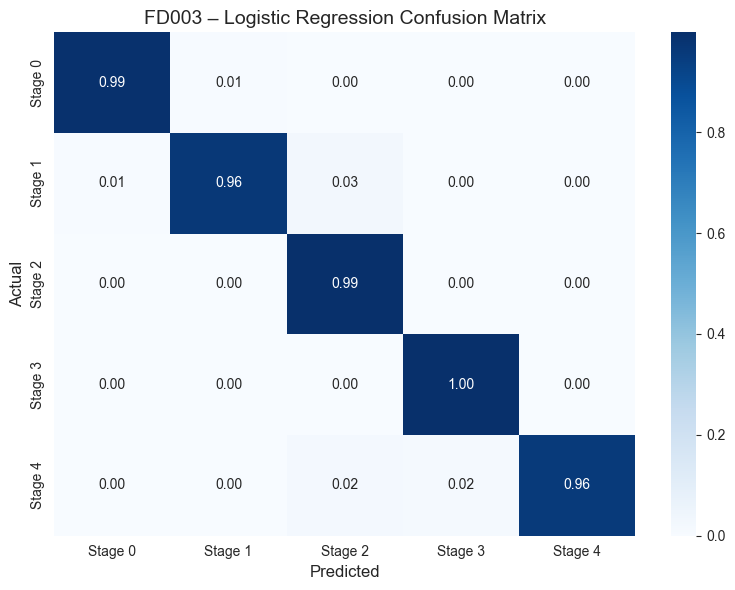

✅ Logistic Regression model, logs, and plots saved for FD003.


In [7]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

# --- Model ---
lr_clf = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=RANDOM_STATE
)

# --- CV ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(lr_clf, X_train_fd003, y_train_fd003, cv=cv, scoring='f1_weighted')
print("LR 5-Fold CV F1 Scores:", cv_scores)
print("LR Mean F1 Score: {:.4f}".format(cv_scores.mean()))

# --- Train ---
lr_clf.fit(X_train_fd003, y_train_fd003)

# --- Predict ---
y_pred = lr_clf.predict(X_val_fd003)
proba = lr_clf.predict_proba(X_val_fd003)
stage4_idx = list(lr_clf.classes_).index(4)
prob_stage4 = proba[:, stage4_idx]
confidence = proba.max(axis=1)

# --- Evaluate ---
print("\nClassification Report:")
print(classification_report(y_val_fd003, y_pred))
report = classification_report(y_val_fd003, y_pred, output_dict=True)
print(f"Stage 3 F1 Score: {report['3']['f1-score']:.4f}")
print(f"Stage 4 F1 Score: {report['4']['f1-score']:.4f}")

# --- Confusion Matrix ---
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(y_val_fd003, y_pred, labels=labels, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f"Stage {l}" for l in labels],
            yticklabels=[f"Stage {l}" for l in labels])
plt.title("FD003 – Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

# --- Save Model and Plot ---
model_path = os.path.join(MODELS_DIR, 'logreg_classifier_fd003.pkl')
fig_path = os.path.join(FIGURES_DIR, 'logreg_fd003_confusion_matrix.png')
joblib.dump(lr_clf, model_path)
plt.savefig(fig_path)
plt.show()
plt.close()

# --- Logs ---
val_df = val_df.reset_index(drop=True)
val_df['y_true'] = y_val_fd003.values
val_df['y_pred'] = y_pred
val_df['prob_Stage4'] = prob_stage4
val_df['confidence'] = confidence
val_df.to_csv(os.path.join(CLASSIF_REPORT_DIR, 'predictions_fd003_logreg.csv'), index=False)
val_df[val_df['y_true'] != val_df['y_pred']].to_csv(os.path.join(CLASSIF_REPORT_DIR, 'misclassified_fd003_logreg.csv'), index=False)
print("✅ Logistic Regression model, logs, and plots saved for FD003.")

## Step 7: XGBoost Classifier
Train an XGBoost classifier with label encoding and evaluate it.

XGBoost Label Mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4)}
XGBoost 5-Fold CV F1 Scores: [0.97351265 0.97347801 0.9788264  0.97351404 0.9740162 ]
XGBoost CV Mean F1 Score: 0.9747

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       257
           1       0.98      0.96      0.97       356
           2       0.97      0.98      0.97       990
           3       0.99      0.99      0.99      1433
           4       0.98      0.98      0.98      1839

    accuracy                           0.98      4875
   macro avg       0.98      0.97      0.98      4875
weighted avg       0.98      0.98      0.98      4875

Stage 3 F1 Score: 0.9885
Stage 4 F1 Score: 0.9779


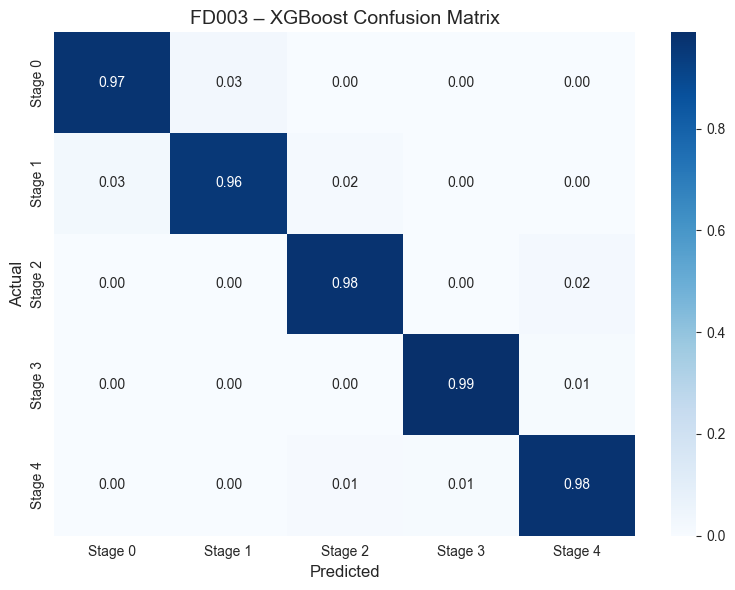

✅ XGBoost model, logs, and plots saved for FD003.


In [8]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# --- Label Encoding ---
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_fd003)
y_val_enc = le.transform(y_val_fd003)
stage_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("XGBoost Label Mapping:", stage_map)

# --- Model ---
xgb_clf = XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    verbosity=0
)

# --- Cross-Validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
xgb_cv_scores = cross_val_score(xgb_clf, X_train_fd003, y_train_enc, cv=cv, scoring='f1_weighted')
print("XGBoost 5-Fold CV F1 Scores:", xgb_cv_scores)
print("XGBoost CV Mean F1 Score: {:.4f}".format(xgb_cv_scores.mean()))

# --- Train ---
xgb_clf.fit(X_train_fd003, y_train_enc)

# --- Predict ---
y_pred_enc = xgb_clf.predict(X_val_fd003)
y_pred = le.inverse_transform(y_pred_enc)
y_true = le.inverse_transform(y_val_enc)

# --- Probabilities ---
proba = xgb_clf.predict_proba(X_val_fd003)
stage4_index = list(le.classes_).index(4)
prob_stage4 = proba[:, stage4_index]
confidence = proba.max(axis=1)

# --- Evaluation ---
print("\nXGBoost Classification Report:")
print(classification_report(y_true, y_pred))
report = classification_report(y_true, y_pred, output_dict=True)
print(f"Stage 3 F1 Score: {report['3']['f1-score']:.4f}")
print(f"Stage 4 F1 Score: {report['4']['f1-score']:.4f}")

# --- Confusion Matrix ---
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(y_val_enc, y_pred_enc, labels=labels, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f"Stage {l}" for l in labels],
            yticklabels=[f"Stage {l}" for l in labels])
plt.title("FD003 – XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

# --- Save Model and Plot ---
model_path = os.path.join(MODELS_DIR, 'xgb_classifier_fd003.pkl')
fig_path = os.path.join(FIGURES_DIR, 'xgb_fd003_confusion_matrix.png')
joblib.dump(xgb_clf, model_path)
plt.savefig(fig_path)
plt.show()
plt.close()

# --- Save Logs ---
val_df = val_df.reset_index(drop=True)
val_df['y_true'] = y_true
val_df['y_pred'] = y_pred
val_df['prob_Stage4'] = prob_stage4
val_df['confidence'] = confidence
val_df.to_csv(os.path.join(CLASSIF_REPORT_DIR, 'predictions_fd003_xgb.csv'), index=False)
val_df[val_df['y_true'] != val_df['y_pred']].to_csv(os.path.join(CLASSIF_REPORT_DIR, 'misclassified_fd003_xgb.csv'), index=False)
print("✅ XGBoost model, logs, and plots saved for FD003.")

✅ Full metrics comparison saved: c:\Users\pandr\hybrid-predictive-maintenance\report\classification\FD003\model_comparison_fd003_all_metrics.csv


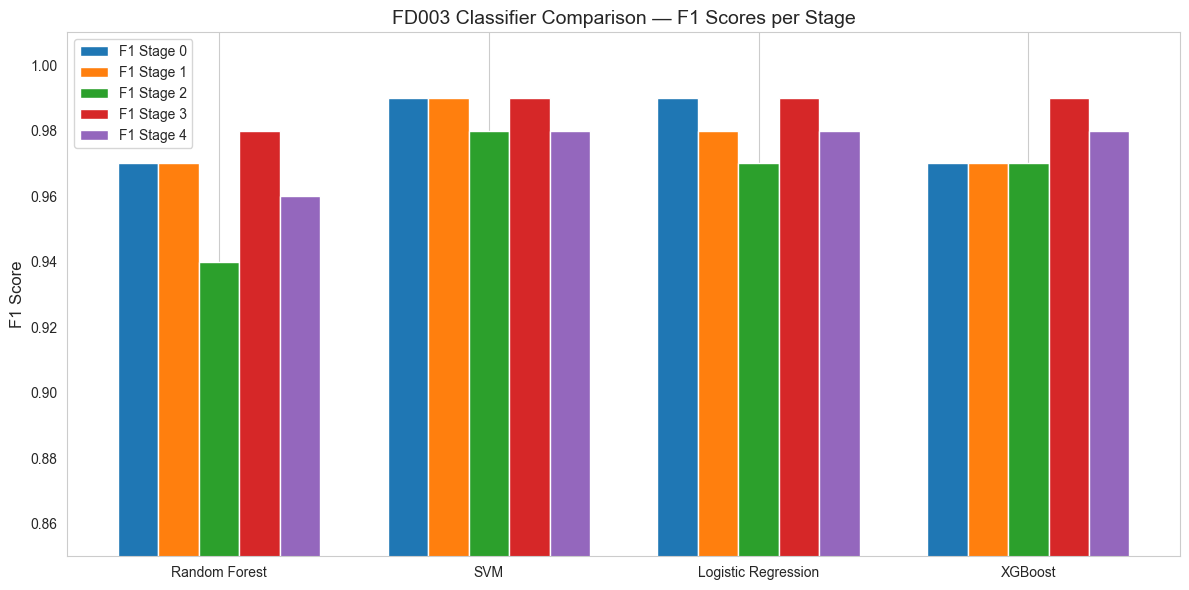

✅ F1 comparison plot saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\fd003_model_f1_scores_by_stage.png


In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# --- Correct Directory Setup ---
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
REPORT_DIR = os.path.join(BASE_DIR, 'report', 'classification', 'FD003')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Metrics from Classification Reports (Updated with actual results) ---
data = {
    'Model': ['Random Forest', 'SVM', 'Logistic Regression', 'XGBoost'],
    'F1_Stage_0': [0.97, 0.99, 0.99, 0.97],  # F1-scores from classification reports
    'F1_Stage_1': [0.97, 0.99, 0.98, 0.97],
    'F1_Stage_2': [0.94, 0.98, 0.97, 0.97],
    'F1_Stage_3': [0.98, 0.99, 0.99, 0.99],
    'F1_Stage_4': [0.96, 0.98, 0.98, 0.98],
    'Macro Precision': [0.96, 0.99, 0.98, 0.98],  # Macro averages from classification reports
    'Macro Recall': [0.96, 0.99, 0.98, 0.97],
    'Macro F1': [0.96, 0.99, 0.98, 0.98],
    'Test Accuracy': [0.96, 0.99, 0.98, 0.98],  # Overall accuracy
    'CV Mean F1 Score': [0.9604, 0.9814, 0.9736, 0.9747]  # Mean F1 scores from 5-fold CV
}

# --- Save Full Comparison Table ---
df_full = pd.DataFrame(data)
csv_path = os.path.join(REPORT_DIR, 'model_comparison_fd003_all_metrics.csv')
df_full.to_csv(csv_path, index=False)
print(f"✅ Full metrics comparison saved: {csv_path}")

# --- Plot: F1 Scores per Stage ---
f1_cols = ['F1_Stage_0', 'F1_Stage_1', 'F1_Stage_2', 'F1_Stage_3', 'F1_Stage_4']
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.15
x = range(len(df_full))

for i, col in enumerate(f1_cols):
    ax.bar(
        [p + bar_width * i for p in x],
        df_full[col],
        width=bar_width,
        label=col.replace('_', ' ')
    )

ax.set_xticks([p + bar_width * 2 for p in x])
ax.set_xticklabels(df_full['Model'])
ax.set_ylim(0.85, 1.01)
ax.set_ylabel("F1 Score")
ax.set_title("FD003 Classifier Comparison — F1 Scores per Stage")
ax.legend()
ax.grid(axis='y')

# --- Save and Show Plot ---
plot_path_f1 = os.path.join(FIGURES_DIR, 'fd003_model_f1_scores_by_stage.png')
plt.tight_layout()
plt.savefig(plot_path_f1)
plt.show()
print(f"✅ F1 comparison plot saved: {plot_path_f1}")

# TEST DATASET — FD003
Apply the trained classifier to the FD003 test dataset and evaluate its performance.

SVM classifier loaded from: c:\Users\pandr\hybrid-predictive-maintenance\models\svm_classifier_fd003.pkl
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       151
           1       0.97      0.99      0.98       621
           2       0.95      0.99      0.97      3065
           3       0.97      1.00      0.98      3131
           4       1.00      0.97      0.99      9628

    accuracy                           0.98     16596
   macro avg       0.97      0.99      0.98     16596
weighted avg       0.98      0.98      0.98     16596



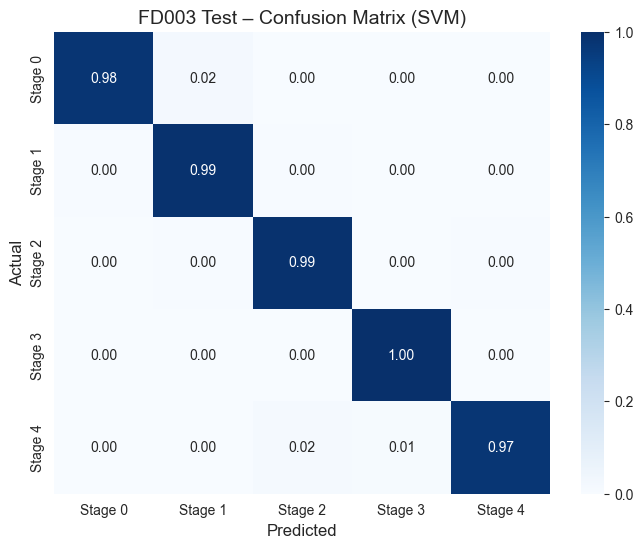

Prediction log saved: c:\Users\pandr\hybrid-predictive-maintenance\report\classification\FD003\test\predictions_test_fd003.csv
Misclassified samples saved: c:\Users\pandr\hybrid-predictive-maintenance\report\classification\FD003\test\misclassified_test_fd003.csv
✅ Test dataset classification for FD003 completed with probabilities.


In [11]:
import pandas as pd
import os
import joblib
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Set the base directory (adjust as needed)
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))

# Define paths for data, models, reports, and figures
TEST_DATA_PATH = os.path.join(BASE_DIR, 'data', 'test_stage_predictions', 'final_stage_test_FD003.csv')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
REPORT_DIR = os.path.join(BASE_DIR, 'report', 'classification', 'FD003', 'test')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3', 'test')

# Create report and figures directories if they don’t exist
os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Load the test dataset
test_df = pd.read_csv(TEST_DATA_PATH)

# Select sensor features (same as used in training)
selected_features = [col for col in test_df.columns if col.startswith("sensor_")]
X_test = test_df[selected_features]  # Features for prediction
y_test = test_df['final_stage']     # Ground truth labels

# Load the trained SVM classifier (best performer in training phase)
model_path = os.path.join(MODELS_DIR, 'svm_classifier_fd003.pkl')
clf = joblib.load(model_path)
print(f"SVM classifier loaded from: {model_path}")

# Predict degradation stages
y_pred = clf.predict(X_test)

# Predict probabilities for all classes
proba = clf.predict_proba(X_test)

# Extract probability for stage 4 (critical failure stage)
stage4_idx = list(clf.classes_).index(4)
prob_stage4 = proba[:, stage4_idx]

# Calculate confidence as the maximum probability across all classes
confidence = proba.max(axis=1)

# Evaluate performance with classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Generate and plot confusion matrix with corrected color scaling
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3, 4], normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', vmin=0.0, vmax=1.0,
            xticklabels=[f"Stage {i}" for i in range(5)],
            yticklabels=[f"Stage {i}" for i in range(5)])
plt.title("FD003 Test – Confusion Matrix (SVM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Save the confusion matrix plot
plt.savefig(os.path.join(FIGURES_DIR, 'fd003_test_confusion_matrix.png'))
plt.show()  # Optionally display the plot
plt.close()  # Close the plot to free up memory

# Add predictions and probabilities to the dataframe
test_df['y_pred'] = y_pred
test_df['prob_stage4'] = prob_stage4
test_df['confidence'] = confidence

# Save the updated dataframe with predictions and probabilities
test_df.to_csv(os.path.join(REPORT_DIR, 'predictions_test_fd003.csv'), index=False)

# Save misclassified samples (including probabilities)
misclassified = test_df[test_df['final_stage'] != test_df['y_pred']]
misclassified.to_csv(os.path.join(REPORT_DIR, 'misclassified_test_fd003.csv'), index=False)

print(f"Prediction log saved: {os.path.join(REPORT_DIR, 'predictions_test_fd003.csv')}")
print(f"Misclassified samples saved: {os.path.join(REPORT_DIR, 'misclassified_test_fd003.csv')}")
print("✅ Test dataset classification for FD003 completed with probabilities.")